In [ ]:
import os, pickle, tempfile
import pandas as pd

In [ ]:
import sys

sys.path.append("../../training_data")

In [ ]:
from utils.utils import Cif, CifFileWriter
from utils.pocket_utils import Pocket

# Data

In [ ]:
extra_set_path = "../../training_data/7.Extra_set"

In [ ]:
with open(f"{extra_set_path}/features.pkl", "rb") as f:
    news = pickle.load(f)

len(news), news

(30,
 {'21du':     Residues                                                          \
           pdb label_entity_id label_asym_id label_seq_id auth_asym_id   
  0       21du               5             E          264            R   
  1       21du               5             E          265            R   
  2       21du               5             E          266            R   
  3       21du               5             E          267            R   
  4       21du               5             E          268            R   
  ..       ...             ...           ...          ...          ...   
  273     21du               5             E          546            R   
  274     21du               5             E          547            R   
  275     21du               5             E          548            R   
  276     21du               5             E          549            R   
  277     21du               5             E          550            R   
  
                      

In [ ]:
with open(f"{extra_set_path}/news_sites.pkl", "rb") as f:
    news_sites = {k: v for k,v in pickle.load(f).items() if k in news}

len(news_sites), news_sites

(30,
 {'22mj': [{'mod':      label_comp_id label_asym_id label_entity_id label_seq_id  \
    2394         A1MDP             H               4            .   
    
         pdbx_PDB_ins_code auth_seq_id auth_comp_id auth_asym_id  \
    2394                 ?         407        A1MDP            A   
    
         pdbx_PDB_model_num pdbx_label_index  
    2394                  1              407  ,
    'site':    label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
    0            THR             A               1          118                 ?   
    1            PRO             A               1          119                 ?   
    2            THR             A               1          120                 ?   
    3            LYS             A               1          129                 ?   
    4            GLY             A               1          130                 ?   
    5            GLY             A               1          131                 ?  

In [ ]:
assert all(len(sites) == 1 for sites in news_sites.values()), "Not all apos have a single annotated site"

In [ ]:
models = pd.read_pickle("models.pkl")

models

{'model5': {'results': {'21du': {'pocket7': {'prob': 0.0001382207265123725,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.0,
     'pocket_in_site': 0.0,
     'site_in_pocket': 0.0},
    'pocket1': {'prob': 0.10166584700345993,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.0,
     'pocket_in_site': 0.0,
     'site_in_pocket': 0.0},
    'pocket2': {'prob': 0.00014608402852900326,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.0,
     'pocket_in_site': 0.0,
     'site_in_pocket': 0.0},
    'pocket4': {'prob': 1.4690601801703451e-06,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.0,
     'pocket_in_site': 0.0,
     'site_in_pocket': 0.0},
    'pocket9': {'prob': 0.0009650973370298743,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.0,
     'pocket_in_site': 0.0,
     'site_in_pocket': 0.0},
    'pocket10': {'prob': 2.846432209935301e-07,
     'pred': 0,
     'label': 0,
     'max_overlap': 0.0,
     'pocket_in_site': 0.0,
     'site_in_pocket': 0.0}

In [ ]:
colors = {
    "orange": "#D55E00".lower(),
    "green": "#009E73".lower(),
    "blue": "#0072B2".lower(),
    "yellow": "#F0E442".lower()
}

# Labelling

In [ ]:
# Percentage of residues of "one" in "other"
get_overlap = lambda one, other: (
    len( one.merge(other) ) / len(one)
)

def get_label(overlaps, site_in_pocket=None, pocket_in_site=None):
    assert not (site_in_pocket==None and pocket_in_site==None)
    
    if site_in_pocket is None:
        return int( overlaps["pocket_in_site"] >= pocket_in_site )
    if pocket_in_site is None:
        return int( overlaps["site_in_pocket"] >= site_in_pocket )
    return int( overlaps["site_in_pocket"] >= site_in_pocket or overlaps["pocket_in_site"] >= pocket_in_site )

In [ ]:
models["model5"]["labelled"]

,pdb,pocket,prob,pred,label,max_overlap,pocket_in_site,site_in_pocket,rank
0,21du,pocket7,0.000138,0,0,0.000000,0.000000,0.000000,4
1,21du,pocket1,0.101666,1,0,0.000000,0.000000,0.000000,10
2,21du,pocket2,0.000146,0,0,0.000000,0.000000,0.000000,5
3,21du,pocket4,0.000001,0,0,0.000000,0.000000,0.000000,2
4,21du,pocket9,0.000965,0,0,0.000000,0.000000,0.000000,7
...,...,...,...,...,...,...,...,...,...
588,9prs,pocket5,0.000003,0,0,0.000000,0.000000,0.000000,3
589,9prs,pocket8,0.000089,0,0,0.000000,0.000000,0.000000,6
590,9prs,pocket3,0.001303,0,0,0.187500,0.187500,0.090909,8
591,9prs,pocket12,0.001842,0,0,0.076923,0.076923,0.030303,10


# Scatters

## Ortho sites

In [ ]:
ortho_sites_path = "ortho_sites"
os.makedirs(ortho_sites_path, exist_ok=True)

In [ ]:
ortho_sitesf = f"{ortho_sites_path}/ortho_sites.pkl"

if os.path.isfile(ortho_sitesf):
    ortho_sites = {k: v for k,v in pd.read_pickle(ortho_sitesf).items() if k in news_sites}
else:
    ortho_sites = {}

ortho_sites.keys()

dict_keys(['7gqu', '8f4s', '8uk6', '8v81', '9ebs', '9mfs', '9oul', '22mj', '6s3a', '6z1m', '7p2v', '7qpn', '7zpe', '8crc', '8fpi', '21du', '8y6w', '9dol', '9prs', '7f8p', '7u4k', '7v39', '8cgw', '9o2m'])

In [ ]:
import pymol2

In [ ]:
def get_orthosite_self(ciff, pdb, chain):
    cif = Cif(pdb, ciff)
    
    with pymol2.PyMOL() as pymol:
        pymol.cmd.feedback(
            "disable", "executive", "details"
        )  # to silence "ExecutiveLoad-Detail: Detected mmCIF"
        pymol.cmd.load(ciff, "prot")
    
        site_atoms = pymol.cmd.get_model(f"(br. all within 6 of segi {'+'.join(chain)}) and polymer.protein")
    
        # Process the atom selection to obtain residue identifiers
        site_list = set(
            tuple(
                (
                    a.segi, a.chain, a.resn,
                    a.resi_number, a.ins_code or '?' # pdbx_PDB_ins_code or "?" if none
                ) 
                for a in site_atoms.atom
            )
        )
    
        if len(site_list) == 0:
            raise EmptySite("Site selection doesn't have any residues")
    
        # Transform the PyMOL-derived residue identifiers into a standard table of residues that can be used to retrieve the rows/residues from the parent structure's .residues table
        return cif.residues.merge(
            pd.DataFrame(
                site_list,
                columns=[
                    "label_asym_id", "auth_asym_id", "auth_comp_id",
                    "auth_seq_id", "pdbx_PDB_ins_code"
                ],
                dtype=str
            )
        )

In [ ]:
def get_orthosite(origcif, origciff, pdb, chain):
    cif = Cif(origcif, origciff)

    with pymol2.PyMOL() as pymol:
        pymol.cmd.feedback(
            "disable", "executive", "details"
        )  # to silence "ExecutiveLoad-Detail: Detected mmCIF"
    
        pymol.cmd.load(origciff, "origcif")
        pymol.cmd.load(f"{ortho_sites_path}/{pdb}_updated.cif", "newcif")
    
        pymol.cmd.align("newcif", "origcif")  # or align / cealign / fit
        if origcif == "8fpi":
            pymol.cmd.super("newcif", "origcif") 

        segi_map = {old: f"ZZ{i+1}" for i, old in enumerate(chain)}
        for oldsegi, newsegi in segi_map.items():
            pymol.cmd.alter(
                f"newcif and segi {oldsegi}",
                f"segi='{newsegi}'",
                # space={"segi_map": segi_map},
            )
            
        pymol.cmd.sort("newcif") # apparently needed after altering IDs
        pymol.cmd.save(f"{ortho_sites_path}/{origcif}_{pdb}.pse", "origcif newcif")
    
        site_atoms = pymol.cmd.get_model(
            f"br. ((origcif and polymer.protein) within 6 of (newcif and segi {'+'.join(segi_map.values())}))"
        )
        
        # Process the atom selection to obtain residue identifiers
        site_list = set(
            tuple(
                (
                    a.segi, a.chain, a.resn,
                    a.resi_number, a.ins_code or '?' # pdbx_PDB_ins_code or "?" if none
                ) 
                for a in site_atoms.atom
            )
        )
    
        if len(site_list) == 0:
            raise Exception((origcif, pdb, segi_map))
    
        # Transform the PyMOL-derived residue identifiers into a standard table of residues that can be used to retrieve the rows/residues from the parent structure's .residues table
        return cif.residues.merge(
            pd.DataFrame(
                site_list,
                columns=[
                    "label_asym_id", "auth_asym_id", "auth_comp_id",
                    "auth_seq_id", "pdbx_PDB_ins_code"
                ],
                dtype=str
            )
        )

In [ ]:
for holo, (pdb, chains) in (
    ("21du", ("8x9s", ["E"])), # not active site, just "orthosteric"
    ("22mj", ("1i9z", ["C"])),
    ("6s3a", ("5grb", ["G"])),
    # 6vvq active site not in structure
    ("6z1m", ("4ptv", ["D"])), # also "C" but for some reason superposition is on 4ptv chain B
    # 7e40 no active site
    ("7f8p", ("7f8p", ["C"])),
    ("7gqu", ("7gqu", ["C"])),
    ("7p2v", ("7p2v", ["B", "E"])),
    ("7qpn", ("3x01", ["C"])),
    ("7u4k", ("2gs3", ["B"])), # a chloride; also ("6hkq", ["B"]) a ligand
    ("7v39", ("4gv3", ["A"])), # a strand of dsDNA
    # 7yg5
    ("7zpe", ("8f5f", ["C", "D"])),
    ("8cgw", ("4p8q", ["O"])), # also "V" for some reason superposition is on chain B
    ("8crc", ("3hih", ["C", "F"])),
    ("8f4s", ("6wks", ["E"])),
    ("8fpi", ("1nb6", ["H"])), # https://doi.org/10.1016/j.cell.2019.08.014 # also "E" but for some reason superposition is on chain B
    # 8jp0
    # 8qni ## now 8qtk
    ("8uk6", ("1euy", ["C"])),
    ("8v81", ("8v81", ["C", "E"])), # ["B",  "D"] is the degenerate non-catalytic site: https://journals.physiology.org/doi/full/10.1152/physrev.00007.2018
    ('8y6w', ('8y6w', ["F"])), # not active site, just "orthosteric"
    ('9dol', ('2dex', ["B"])),
    ("9ebs", ("9ebs", ["D"])),
    # 9fsj
    ("9mfs", ("9mfs", ["C", "D"])),
    ("9o2m", ("5e9b", ["C"])),
    ("9oul", ("9oul", ["E"])), # not active site, just "orthosteric"
    ("9prs", ("9prs", ["B"])), # substitutes 9ntc ("9ntc", ("9ntc", ["C"])), # not active site, just "primary"
):
    if holo not in ortho_sites:
        cif = Cif(holo, f"../../training_data/7.Extra_set/cifs/{holo}.cif")
        
        if pdb == holo:
            ciff = f"../../training_data/7.Extra_set/origcifs/{holo}_updated.cif.gz"
            ortho_sites[holo] = [
                get_orthosite_self(ciff, pdb, chain)
                for chain in (chains if isinstance(chains[0], list) else [chains])
            ]
            
        else:
            newciff = f"{ortho_sites_path}/{pdb}_updated.cif"
            if not os.path.isfile(newciff):
                os.system(f"wget https://www.ebi.ac.uk/pdbe/entry-files/download/{pdb}_updated.cif -O {newciff}")

            ortho_sites[holo] = [
                get_orthosite(holo, cif.filename, pdb, chain)
                for chain in  (chains if isinstance(chains[0], list) else [chains])
            ]
            
        pd.to_pickle(ortho_sites, ortho_sitesf)

In [ ]:
{k: {i: len(v2) for i, v2 in enumerate(v, 1)} for k, v in ortho_sites.items()}, ortho_sites

({'7gqu': {1: 21},
  '8f4s': {1: 30},
  '8uk6': {1: 31},
  '8v81': {1: 28},
  '9ebs': {1: 14},
  '9mfs': {1: 27},
  '9oul': {1: 14},
  '22mj': {1: 13},
  '6s3a': {1: 18},
  '6z1m': {1: 26},
  '7p2v': {1: 20},
  '7qpn': {1: 25},
  '7zpe': {1: 28},
  '8crc': {1: 11},
  '8fpi': {1: 17},
  '21du': {1: 21},
  '8y6w': {1: 25},
  '9dol': {1: 20},
  '9prs': {1: 19},
  '7f8p': {1: 20},
  '7u4k': {1: 11},
  '7v39': {1: 25},
  '8cgw': {1: 12},
  '9o2m': {1: 19}},
 {'7gqu': [   label_comp_id label_asym_id label_entity_id label_seq_id pdbx_PDB_ins_code  \
   0            LEU             A               1           25                 ?   
   1            HIS             A               1           31                 ?   
   2            SER             A               1           32                 ?   
   3            SER             A               1           33                 ?   
   4            PHE             A               1           34                 ?   
   5            LYS            

In [ ]:
ortho_labels = {}

for pdb, pdbd in models["model5"]["results"].items():
    if pdb not in ortho_sites: continue
        
    ortho_sites_pdb = ortho_sites[pdb]
    ortho_labels[pdb] = {}
    
    for pocket, pocketd in pdbd.items():
        pocketres = Pocket(f"../../training_data/7.Extra_set/pockets/{pdb}/{pdb}_out/pockets/{pocket}_atm.cif").residues

        overlaps = max(
            (
                {
                    name: get_overlap(*one_in_other)
                        for name, one_in_other in (
                            ("pocket_in_site", (pocketres, site)),
                            ("site_in_pocket", (site, pocketres)),
                        )
                }
                for site in ortho_sites_pdb
            ),
            key=lambda x: x["site_in_pocket"]
        )
        
        ortho_labels[pdb][pocket] = {
            "ortho_label": get_label(overlaps, site_in_pocket=0.65, pocket_in_site=None),
            "ortho_max_overlap": max(overlaps.values()),
            **{f"ortho_{k}": v for k, v in overlaps.items()},
            **pocketd
        }

ortho_labels.keys(), ortho_labels

(dict_keys(['21du', '22mj', '6s3a', '6z1m', '7f8p', '7gqu', '7p2v', '7qpn', '7u4k', '7v39', '7zpe', '8cgw', '8crc', '8f4s', '8fpi', '8uk6', '8v81', '8y6w', '9dol', '9ebs', '9mfs', '9o2m', '9oul', '9prs']),
 {'21du': {'pocket7': {'ortho_label': 0,
    'ortho_max_overlap': 0.0,
    'ortho_pocket_in_site': 0.0,
    'ortho_site_in_pocket': 0.0,
    'prob': 0.0001382207265123725,
    'pred': 0,
    'label': 0,
    'max_overlap': 0.0,
    'pocket_in_site': 0.0,
    'site_in_pocket': 0.0},
   'pocket1': {'ortho_label': 0,
    'ortho_max_overlap': 0.42857142857142855,
    'ortho_pocket_in_site': 0.42857142857142855,
    'ortho_site_in_pocket': 0.42857142857142855,
    'prob': 0.10166584700345993,
    'pred': 0,
    'label': 0,
    'max_overlap': 0.0,
    'pocket_in_site': 0.0,
    'site_in_pocket': 0.0},
   'pocket2': {'ortho_label': 0,
    'ortho_max_overlap': 0.0,
    'ortho_pocket_in_site': 0.0,
    'ortho_site_in_pocket': 0.0,
    'prob': 0.00014608402852900326,
    'pred': 0,
    'label':

In [ ]:
ortho_df = pd.DataFrame((
    {
        "pdb": pdb,
        "pocket": pocket,
        **pocketd
    }
    for pdb, pockets in ortho_labels.items()
    for pocket, pocketd in pockets.items()
))

ortho_df.sort_values("ortho_max_overlap", ascending=False).iloc[:40]

,pdb,pocket,ortho_label,ortho_max_overlap,ortho_pocket_in_site,ortho_site_in_pocket,prob,pred,label,max_overlap,pocket_in_site,site_in_pocket
72,7p2v,pocket5,1,1.000000,1.000000,0.800000,1.674823e-02,0,0,0.000000,0.000000,0.000000
53,7gqu,pocket1,1,0.952381,0.162602,0.952381,9.329672e-01,1,1,0.896552,0.211382,0.896552
427,9prs,pocket1,1,0.947368,0.409091,0.947368,9.091328e-01,1,1,0.727273,0.545455,0.727273
295,8v81,pocket43,1,0.928571,0.247619,0.928571,4.877561e-01,0,0,0.000000,0.000000,0.000000
66,7p2v,pocket14,0,0.888889,0.888889,0.400000,4.323507e-04,0,0,0.000000,0.000000,0.000000
321,8y6w,pocket6,1,0.880000,0.846154,0.880000,7.960428e-01,1,0,0.000000,0.000000,0.000000
106,7zpe,pocket2,0,0.823529,0.823529,0.500000,3.675533e-01,0,0,0.142857,0.117647,0.142857
372,9mfs,pocket2,1,0.814815,0.226804,0.814815,9.858177e-01,1,0,0.043478,0.010309,0.043478
351,9ebs,pocket10,1,0.785714,0.478261,0.785714,1.800500e-02,0,0,0.000000,0.000000,0.000000
422,9oul,pocket12,1,0.785714,0.733333,0.785714,9.503002e-02,0,0,0.000000,0.000000,0.000000


In [ ]:
ortho_pockets = {
    "21du": ("pocket5",),
    "22mj": ("pocket9",),
    # 6s3a no pocket overlaps with active site (superficial)
    "6z1m": ("pocket14",),
    '7f8p': ("pocket1",),
    "7gqu": ("pocket1",), # coincides with allosteric site
    "7p2v": ("pocket5",),
    "7qpn": ("pocket12",),
    # '7u4k', no pocket overlaps with active site
    '7v39': ("pocket2",),
    "7zpe": ("pocket2",),
    # '8cgw', no pocket overlaps with the active site
    # 8crc no pocket overlaps with active site, adjacent to the allosteric-labelled
    "8f4s": ("pocket2",),
    "8fpi": ("pocket26",),
    "8uk6": ("pocket3",),
    "8v81": ("pocket43",), # , "pocket17"
    "8y6w": ("pocket6",),
    "9dol": ("pocket1",),
    "9ebs": ("pocket10",),
    "9mfs": ("pocket2",),
    '9o2m': ("pocket8",),
    "9oul": ("pocket12",),
    "9prs": ("pocket1",), # "9ntc": ("pocket1",), # coincides with allosteric site
}

ortho_pocketsf = "ortho_pockets.pkl"
pd.to_pickle(ortho_pockets, ortho_pocketsf)

ortho_pockets

{'21du': ('pocket5',),
 '22mj': ('pocket9',),
 '6z1m': ('pocket14',),
 '7f8p': ('pocket1',),
 '7gqu': ('pocket1',),
 '7p2v': ('pocket5',),
 '7qpn': ('pocket12',),
 '7v39': ('pocket2',),
 '7zpe': ('pocket2',),
 '8f4s': ('pocket2',),
 '8fpi': ('pocket26',),
 '8uk6': ('pocket3',),
 '8v81': ('pocket43',),
 '8y6w': ('pocket6',),
 '9dol': ('pocket1',),
 '9ebs': ('pocket10',),
 '9mfs': ('pocket2',),
 '9o2m': ('pocket8',),
 '9oul': ('pocket12',),
 '9prs': ('pocket1',)}

## Plots

In [ ]:
df = models["model5"]["labelled"]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import MaxNLocator

scatter_config = {
    "figsize": (1.75, 2.25),
    "point_size": 50,
    "jitter_width": 0.2,
    "grey_alpha": 0.4,
    "axis_linewidth": 0.8,
    "tick_fontsize": 12,
    "label_fontsize": 15,
    "xlabel_fontsize": 12,
    "score_title_fontsize": 13,
    "score_title_y": 1.12,
    "annotation_x_offset": 0.4,
    "yticks": [0.0, 0.25, 0.5, 0.75, 1.0],
    "ylabel_right_spine_position": 0.8125,
    "light_grey": "0.75",
    "xlabel_color": "0.35",
    "output_prefix": "images/boxplot_",
    "special_nbins": {"8crc": 1, "7u4k": 1},
    "blue_x_shift_by_pdb": {"9mfs": -0.05},
    "active_allo_pdbs": ("7gqu", "9prs"), # 9ntc
}

plt.rcParams["font.family"] = "Aptos"
rcParams["svg.fonttype"] = "none"
rcParams["axes.linewidth"] = scatter_config["axis_linewidth"]


def get_scatter_point_color(row, light_grey=None):
    light_grey = light_grey or scatter_config["light_grey"]
    if row["pdb"] in ortho_pockets and row["pdb"] not in scatter_config["active_allo_pdbs"]: 
        if row["pocket"] in ortho_pockets[row["pdb"]]:
            return colors["yellow"]
    if row["pred"] and row["label"]:
        return colors["green"]
    if row["label"]:
        return colors["orange"]
    if row["pred"]:
        return colors["blue"]
    return light_grey


def get_beeswarm_offsets(probs, pdb_id, jitter_width, special_nbins=None):
    probs = np.asarray(probs, dtype=float)
    if probs.size == 0 or np.nanmax(probs) == np.nanmin(probs):
        return np.zeros_like(probs)

    nbins = (special_nbins or {}).get(pdb_id, 50)
    rng = np.random.default_rng(0)
    quant = np.round(
        nbins * (probs - np.nanmin(probs)) / (np.nanmax(probs) - np.nanmin(probs) + 1e-8)
    )
    order = np.argsort(quant + rng.normal(0, 1e-6, len(probs)))

    x_vals = np.zeros(len(probs))
    layer = 0
    last_bin = None

    for idx in order:
        if quant[idx] != last_bin:
            layer = 0
            last_bin = quant[idx]

        if layer == 0:
            offset = 0
        else:
            offset = (layer + 1) // 2
            if layer % 2 == 0:
                offset = -offset

        x_vals[idx] = offset
        layer += 1

    max_abs = np.max(np.abs(x_vals))
    if max_abs > 0:
        x_vals = x_vals / max_abs * jitter_width
    return x_vals


def plot_scatter_panel(pdb_id, df, ax=None, config=None, show_xlabel=True, show_score_title=True, save_path=None):
    config = {**scatter_config, **(config or {})}
    sub = df.query("pdb == @pdb_id").copy()
    probs = sub["prob"].to_numpy(dtype=float)
    if len(probs) == 0 or np.all(np.isnan(probs)):
        raise ValueError(f"No valid probabilities found for {pdb_id}")

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=config["figsize"])
    else:
        fig = ax.figure

    rcParams["font.size"] = config["label_fontsize"]
    rcParams["ytick.labelsize"] = config["tick_fontsize"]

    sc_colors = np.array([get_scatter_point_color(row) for _, row in sub.iterrows()], dtype=object)
    alphas = np.array([
        config["grey_alpha"] if color == config["light_grey"] else 1
        for color in sc_colors
    ])
    x_vals = get_beeswarm_offsets(
        probs,
        pdb_id=pdb_id,
        jitter_width=config["jitter_width"],
        special_nbins=config["special_nbins"],
    )

    grey_mask = sc_colors == config["light_grey"]
    blue_mask = sc_colors == colors["blue"]
    color_mask = ~(grey_mask | blue_mask)

    ax.scatter(
        x_vals[grey_mask],
        probs[grey_mask],
        s=config["point_size"],
        c=sc_colors[grey_mask],
        alpha=alphas[grey_mask],
        edgecolors="none",
        zorder=1,
        clip_on=False,
    )

    if np.any(color_mask):
        ax.scatter(
            x_vals[color_mask],
            probs[color_mask],
            s=config["point_size"],
            c=sc_colors[color_mask],
            alpha=alphas[color_mask],
            edgecolors="none",
            zorder=2,
            clip_on=False,
        )

    blue_shift = config["blue_x_shift_by_pdb"].get(pdb_id, 0.0)
    if np.any(blue_mask):
        ax.scatter(
            x_vals[blue_mask] + blue_shift,
            probs[blue_mask],
            s=config["point_size"],
            c=sc_colors[blue_mask],
            alpha=alphas[blue_mask],
            edgecolors="none",
            zorder=3,
            clip_on=False,
        )

    idx_max = int(np.nanargmax(probs))
    text_val = f"{probs[idx_max]:.3f}".rstrip("0").rstrip(".")
    ax.text(
        x_vals[idx_max] - config["jitter_width"] * config["annotation_x_offset"] + blue_shift,
        probs[idx_max],
        text_val,
        ha="right",
        va="center",
        fontsize=config["label_fontsize"],
    )

    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(0, 1)
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["right"].set_visible(True)
    ax.spines["right"].set_linewidth(config["axis_linewidth"])
    ax.spines["right"].set_position(("axes", config["ylabel_right_spine_position"]))

    ax.set_xticks([])
    ax.tick_params(axis="x", which="both", length=0)
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    if config["yticks"] is None:
        ax.yaxis.set_major_locator(MaxNLocator(5))
    else:
        ax.set_yticks(config["yticks"])
        ax.set_yticklabels(["0", "", "0.5", "", "1"])
    ax.tick_params(axis="y", labelsize=config["tick_fontsize"])
    ax.set_ylabel("")
    if show_score_title:
        ax.text(
            0,
            config["score_title_y"],
            "AlloPockets\nscore",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            multialignment="center",
            fontsize=config["score_title_fontsize"],
        )
    ax.set_xlabel(f"(n = {len(sub)})" if show_xlabel else "", fontsize=config["xlabel_fontsize"], color=config["xlabel_color"])
    if show_xlabel:
        ax.xaxis.set_label_coords(0.52, -0.075)

    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    if created_fig:
        fig.tight_layout()
        if save_path is not None:
            fig.savefig(save_path, dpi=300, transparent=True)
        plt.show()
        return fig, ax

    return ax


21du


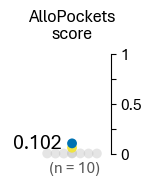

22mj


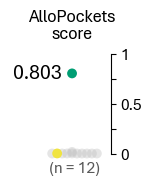

6s3a


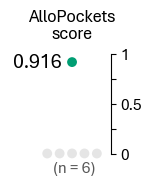

6vvq


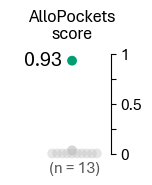

6z1m


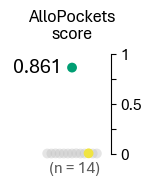

7e40


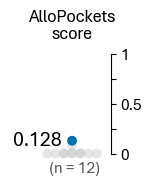

7f8p


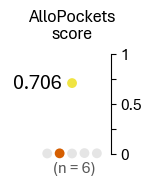

7gqu


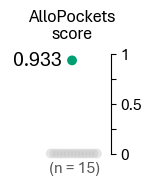

7p2v


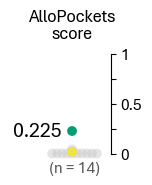

7qpn


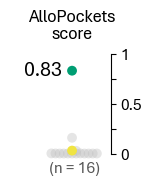

7u4k


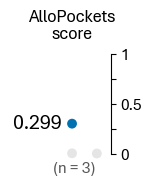

7v39


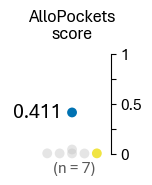

7yg5


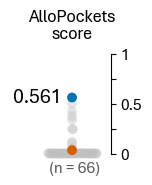

7zpe


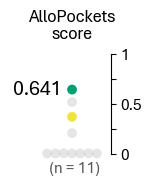

8cgw


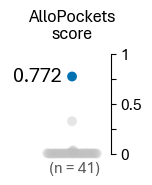

8crc


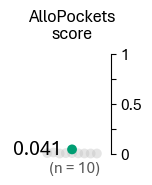

8f4s


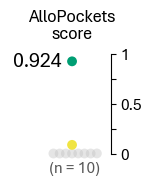

8fpi


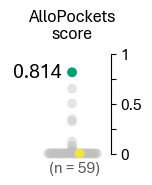

8jp0


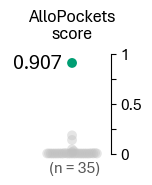

8qtk


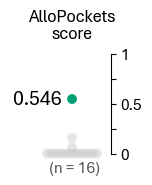

8uk6


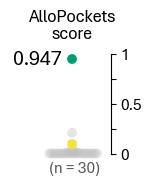

8v81


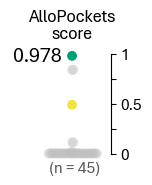

8y6w


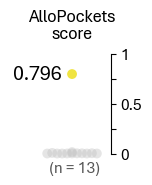

9dol


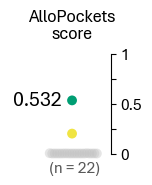

9ebs


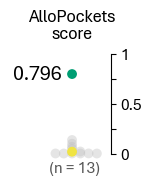

9fsj


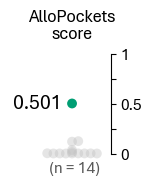

9mfs


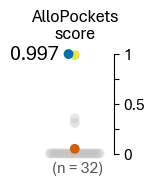

9o2m


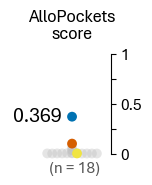

9oul


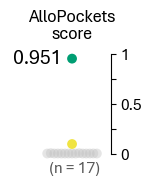

9prs


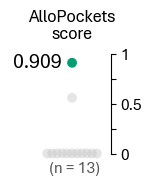

In [ ]:
os.makedirs("images", exist_ok=True)

for pdb_id in df["pdb"].drop_duplicates():
    print(pdb_id)
    plot_scatter_panel(
        pdb_id,
        df,
        # save_path=f"{scatter_config['output_prefix']}{pdb_id}.svg",
    )


## Allo-ortho differences

In [ ]:
df = models["model5"]["labelled"]

pdb_ids = "8v81, 9ebs, 9oul, 6z1m, 7qpn, 8f4s, 9dol, 7zpe, 8fpi, 7p2v, 22mj, 8uk6".split(", ")

rows = []

for pdb in pdb_ids:
    sub = df.query("pdb == @pdb")

    allo = sub.query("label == 1")[["pdb", "pocket", "prob"]]
    ortho = sub[sub["pocket"].isin(ortho_pockets[pdb])][["pdb", "pocket", "prob"]]

    for _, a in allo.iterrows():
        for _, o in ortho.iterrows():
            rows.append({
                "pdb": pdb,
                "allo_pocket": a["pocket"],
                "ortho_pocket": o["pocket"],
                "allo_prob": a["prob"],
                "ortho_prob": o["prob"],
                "diff_allo_minus_ortho": a["prob"] - o["prob"],
            })

diffs = pd.DataFrame(rows)
diffs

,pdb,allo_pocket,ortho_pocket,allo_prob,ortho_prob,diff_allo_minus_ortho
0,8v81,pocket1,pocket43,0.978224,0.487756,0.490468
1,9ebs,pocket7,pocket10,0.796124,0.018005,0.778119
2,9oul,pocket1,pocket12,0.950576,0.095030,0.855546
3,6z1m,pocket6,pocket14,0.860876,0.002004,0.858873
4,7qpn,pocket2,pocket12,0.829702,0.029306,0.800396
5,8f4s,pocket1,pocket2,0.923507,0.086726,0.836781
6,9dol,pocket21,pocket1,0.532278,0.199449,0.332829
7,7zpe,pocket3,pocket2,0.640509,0.367553,0.272956
8,8fpi,pocket1,pocket26,0.813759,0.001711,0.812048
9,7p2v,pocket7,pocket5,0.225498,0.016748,0.208750


In [ ]:
summary = diffs["diff_allo_minus_ortho"].agg(["mean", "std", "count"])

summary

mean      0.658352
std       0.254385
count    12.000000
Name: diff_allo_minus_ortho, dtype: float64

# Pocket functions

In [ ]:
from biotite.structure.io.pdb import PDBFile

def get_pdb_atoms(f):
    atom_array = PDBFile.read(f).get_structure()
    return pd.DataFrame({
            "auth_asym_id": atom_array.chain_id,
            "auth_seq_id": atom_array.res_id,
            "auth_comp_id": atom_array.res_name,
            "auth_atom_id": atom_array.atom_name,
            "type_symbol": atom_array.element,
            "Cartn_x": atom_array.coord[0][:, 0],
            "Cartn_y": atom_array.coord[0][:, 1],
            "Cartn_z": atom_array.coord[0][:, 2],
            "pdbx_PDB_ins_code": (ic or '?' for ic in atom_array.ins_code)
        }, dtype=str)

In [ ]:
def get_pocket(pocket_atoms, res_id, color):
    pocket_atoms["label_entity_id"] = '99'
    return {
        "pocketn": res_id,
        "atoms": pocket_atoms, 
        "representation": {
            "selection": [{'label_entity_id': '99', "auth_asym_id": pocket_atoms.auth_asym_id.unique().item(), 'auth_seq_id': int(res_id)}], 
            'color': colors[color]
        }
    }

In [ ]:
def get_our_pocket(pdb, pocket, color):
    pocketn = pocket.replace('pocket', '')
    # pocket_atoms = (
    #     Cif(pdb, f"{extra_set_path}/pockets/{pdb}/{pdb}_out/{pdb}_out.cif", name=f"{pdb}_out")
    #     .atoms
    #     .query(f"label_comp_id == 'STP' and label_seq_id == '{pocketn}'")
    # )

    return {
        "pocketsf": f"{extra_set_path}/pockets/{pdb}/{pdb}_out/{pdb}_out.cif",
        "pocketn": pocketn,
        "pocket_sel": [{"label_comp_id": 'STP', "label_seq_id": int(pocketn)},],
        "color": colors[color]
    }#get_pocket(pocket_atoms, pocketn, color)
# {
#         "atoms": pocket_atoms, 
#         "representation": {
#             "selection": {'label_entity_id': '99', "auth_asym_id": pocket_atoms.auth_asym_id.unique().item(), 'auth_seq_id': int(pocketn)}, 
#             'color': colors[color]
#         }
#     }

models["model5"]["pocketf"] = get_our_pocket

In [ ]:
def get_allositepro_pocket(pdb, pocket, color):
    resultsf = next(f for f in os.listdir(f"AllositePro/{pdb}") if f.endswith("_download"))
    # pockets are 0-indexed but residue numbers start at 1
    # also pocket0 can be residue ID 2, so all pockets auth_seq_id will be sorted and then the relevant residue id taken with the 0-index pocket number
    pockets_atoms = (
        get_pdb_atoms(f"AllositePro/{pdb}/{resultsf}/{resultsf.replace('_download', '')}.pdb")
        .query(f"auth_comp_id == 'STP'")
    )
    pocketn = sorted(pockets_atoms.auth_seq_id.unique())[ int(pocket.replace('pocket', '')) ]
    # pocket_atoms = pockets_atoms.query(f"auth_seq_id == '{pocketn}'")
    
    return {
        "pocketsf": f"AllositePro/{pdb}/{resultsf}/{resultsf.replace('_download', '')}.pdb",
        "pocketn": pocketn,
        "pocket_sel": [{"auth_comp_id": 'STP', "auth_seq_id": int(pocketn)},],
        "color": colors[color]
    }#get_pocket(pocket_atoms, pocketn, color)

models["allositepro"]["pocketf"] = get_allositepro_pocket

In [ ]:
from functools import partial

In [ ]:
def get_passer_pocket(pdb, pocket, color, model):
    pocketn = pocket.replace('pocket', '')
    # pocket_atoms = (
    #     get_pdb_atoms(f"PASSer/{model}/{pdb}/{pdb}_out.pdb")
    #     .query(f"auth_comp_id == 'STP' and auth_seq_id == '{pocketn}'")
    # )
    
    return {
        "pocketsf": f"PASSer/{model}/{pdb}/{pdb}_out.pdb",
        "pocketn": pocketn,
        "pocket_sel": [{"auth_comp_id": 'STP', "auth_seq_id": int(pocketn)},],
        "color": colors[color]
    }#get_pocket(pocket_atoms, pocketn, color)

models["passer_ensemble"]["pocketf"] = partial(get_passer_pocket, model="ensemble")
models["passer_automl"]["pocketf"] = partial(get_passer_pocket, model="automl")
models["passer_rank"]["pocketf"] = partial(get_passer_pocket, model="rank")

In [ ]:
def get_allo_pocket(pdb, pocket, color):
    resultsf = next(f for f in os.listdir(f"ALLO/{pdb}") if f.startswith(f"{pdb}pdb") and f.endswith("_desc.txt")).replace("_desc.txt", "")
    pocket_atoms = (
        get_pdb_atoms(f"ALLO/{pdb}/pockets/{resultsf}_{pocket}_res.pdb")
    )
    
    # pocket_atoms["auth_asym_id"] = 'ZZZ'
    # pocket_atoms["label_entity_id"] = '99'
    return {
        "pocketsf": f"ALLO/{pdb}/pockets/{resultsf}_{pocket}_res.pdb",
        "pocketn": pocket,
        "pocket_sel": [
            {"auth_asym_id": atom['auth_asym_id'], "auth_seq_id": int(atom['auth_seq_id']), "auth_atom_id": atom['auth_atom_id']}
            for i, atom in pocket_atoms.query("auth_atom_id not in ['CA', 'C', 'O', 'N', 'CB']").iterrows()
        ],
        "color": colors[color]
    }
    #{
    #     "pocketn": pocket,
    #     "atoms": pocket_atoms.query("auth_atom_id not in ['CA', 'C', 'O', 'N', 'CB']"), 
    #     "representation": {
    #         "selection": [
    #             {"auth_asym_id": "ZZZ", 'auth_seq_id': int(res)}
    #             for res in pocket_atoms["auth_seq_id"].unique()
    #         ],
    #         'color': colors[color]
    #     }
    # }

models["allo"]["pocketf"] = get_allo_pocket

In [ ]:
def get_alloses_pocket(pdb, pocket, color):
    pocketn = pocket.replace('pocket', '')
    
    return {
        "pocketsf": f"AllosES/{pdb.upper()}/{pdb.upper()}_out/{pdb.upper()}_out.pdb",
        "pocketn": pocketn,
        "pocket_sel": [{"auth_comp_id": 'STP', "auth_seq_id": int(pocketn)},],
        "color": colors[color]
    }#get_pocket(pocket_atoms, pocketn, color)

models["alloses"]["pocketf"] = get_alloses_pocket

In [ ]:
def get_mefallosite_pocket(pdb, pocket, color):
    pocketn = pocket.replace('pocket', '')
    
    return {
        "pocketsf": f"MEF-AlloSite/MEF-AlloSite/data/test/{pdb.upper()}_cleaned_out/{pdb.upper()}_cleaned_out.pdb",
        "pocketn": pocketn,
        "pocket_sel": [{"auth_comp_id": 'STP', "auth_seq_id": int(pocketn)},],
        "color": colors[color]
    }#get_pocket(pocket_atoms, pocketn, color)

models["mefallosite"]["pocketf"] = get_mefallosite_pocket

# View functions

In [ ]:
import molviewspec as mvs
import json
from pathlib import Path

In [ ]:
# ass_fields_list = ["_pdbx_struct_assembly", "_pdbx_struct_assembly_gen", "_pdbx_struct_oper_list"]

def view_pockets(pdb, model, pockets:list):
    cif = Cif(pdb, f"{extra_set_path}/origcifs/{pdb}_updated.cif.gz")

    # minimal_elements = lambda element="label_asym_id": site["site"][element].unique().tolist() + site["mod"][element].unique().tolist()

    site = news_sites[pdb][0]
    # atoms = cif.atoms.query(f"label_asym_id in {minimal_elements('label_asym_id')}")

    # # Fake entity data
    # entities = pd.concat((
    #     pd.DataFrame(cif.cif.data["_entity"], dtype=str),#.query(f"id in {minimal_elements('label_entity_id')}"),
    #     pd.DataFrame([{"id": "99", "type": "branched", "pdbx_description": "pockets"}]) # Fake the pockets as carbohydrates to manage their representation
    # )).fillna(".")

    

    # columns = list( set.intersection( *map(set, (pocket_atoms["atoms"].columns for pocket_atoms in pockets)) ) )
    # atoms = pd.concat((
    #     cif.atoms[columns],
    #     *(pocket_atoms["atoms"][columns] for pocket_atoms in pockets)
    # ))

    # with tempfile.NamedTemporaryFile("w+", suffix=".cif") as f:
    #     writer = CifFileWriter(f.name)
    #     writer.write({cif.entry_id.upper(): {
    #         "_entity": entities.to_dict(orient="list"),
    #         "_atom_site": atoms.to_dict(orient="list"),
    #         # **{k: cif.cif.data[k] for k in ass_fields_list}
    #     }})
    #     combined = Cif(pdb, filename=f.name)
    #     combined.cif.data # to cache it while 'f' exists

    
    builder = mvs.create_builder()
    builder.canvas(background_color="#FFFFFF") # "#FFFFFF00"
    structure = (
        builder.download(url=f"{pdb}.cif")
        .parse(format="mmcif")
        .model_structure()
    )
    assets = {f'{pdb}.cif': cif.cif.text.encode()}

    if custom_vizs[pdb]["camera"]["camera"]:
        builder.camera(
            **eval(
                "dict("
                + custom_vizs[pdb]["camera"]["camera"].strip()[1:-1].replace(":", "=") 
                + ")"
            )
        )
    if model in custom_vizs[pdb]["camera"]:
        builder.camera(
            **eval(
                "dict("
                + custom_vizs[pdb]["camera"][model].strip()[1:-1].replace(":", "=") 
                + ")"
            )
        )

    # Protein and site
    for auth_asym_id, siteres in site["site"].groupby("auth_asym_id"):
        protein = (
            structure
            .component(selector=[
                mvs.ComponentExpression(**sel)
                for sel in custom_vizs[pdb]["selections"].get(f"protein_{auth_asym_id}", [{"auth_asym_id": auth_asym_id},])
            ])
            .representation(type="cartoon", custom={"molstar_representation_params": {"ignoreLight": True}})#, custom={"ignoreLight": True})
            .color(color='#DADADA')
            # .opacity(opacity=0.95)
        )

        annos = f'annos_chain_{auth_asym_id}.json'
        assets[annos] = json.dumps(
            [
                {
                    'auth_asym_id': r["auth_asym_id"], 'auth_seq_id': int(r["auth_seq_id"]), 
                    'color': 'black' # 'pdbx_PDB_ins_code': r["pdbx_PDB_ins_code"],
                }
                for i, r in siteres.iterrows()
            ]
        ).encode()
        protein.color_from_uri(uri=annos, format='json', schema='all_atomic')

        # if model == "model5":
        for i, osite in enumerate(ortho_sites.get(pdb, [])):
            osite = osite.query(f"auth_asym_id == '{auth_asym_id}'").merge(
                siteres,
                how="left", indicator=True
            ).query("_merge == 'left_only'").drop(columns="_merge")
            
            if len(osite) == 0: continue
            annos = f'ortho_annos_{auth_asym_id}_{i}.json'
            assets[annos] = json.dumps(
                [
                    {
                        'auth_asym_id': r["auth_asym_id"], 'auth_seq_id': int(r["auth_seq_id"]), 
                        'color': colors["yellow"] # 'pdbx_PDB_ins_code': r["pdbx_PDB_ins_code"],
                    }
                    for i, r in osite.iterrows()
                ]
            ).encode()
            protein.color_from_uri(uri=annos, format='json', schema='all_atomic')
            
            
    # Ligands
    if not custom_vizs[pdb]["ligands"]["none"]:
        for entity_id in pd.DataFrame(cif.cif.data["_entity"], dtype=str).query("type == 'non-polymer'").id.unique():
            if entity_id not in site["mod"].label_entity_id.unique():
                (
                    structure
                    .component(selector=mvs.ComponentExpression(label_entity_id=entity_id))
                    .representation(type="ball_and_stick", custom={"molstar_representation_params": {"ignoreLight": True}})
                    .color(color="white")
                )
    ligs = []
    if "model5" in custom_vizs[pdb]["ligands"]:
        ligs += custom_vizs[pdb]["ligands"]["model5"]
    if model in custom_vizs[pdb]["ligands"]:
        ligs += [ml for ml in custom_vizs[pdb]["ligands"][model] if all(ml != l for l in ligs)]
    for lig in ligs:
    # if model in custom_vizs[pdb]["ligands"]:
    #     for lig in custom_vizs[pdb]["ligands"][model]:
        (
            structure
            .component(selector=mvs.ComponentExpression(**lig))
            .representation(
                type="ball_and_stick", 
                size_factor=custom_vizs[pdb]["ligands"].get("size_factor", 0.6),
                custom={"molstar_representation_params": {"ignoreLight": True}})
            .color(
                custom={
                    "molstar_color_theme_name": "element-symbol",
                    "molstar_color_theme_params": {
                        "carbonColor": { "name": "uniform", "params": {"value": int("#808080".replace('#', ''), 16)} }
                    }
                }
            )
            # .opacity(opacity=0.9)
        )
    
    # Modulator
    # for entity_id in entities.query("type == 'non-polymer'").id.unique():
    for asym_id in site["mod"].label_asym_id.unique():
        (
            structure
            .component(selector=
                [mvs.ComponentExpression(label_asym_id=asym_id)]
                + [mvs.ComponentExpression(**covd) for covd in custom_vizs[pdb]["covalent_residues"]]
            )
            .representation(
                type="ball_and_stick", 
                size_factor=custom_vizs[pdb]["ligands"].get("size_factor", 0.6),
                custom={"molstar_representation_params": {"ignoreLight": True}})
            .color(
                custom={
                    "molstar_color_theme_name": "element-symbol",
                    "molstar_color_theme_params": {
                        "carbonColor": { "name": "uniform", "params": {"value": int("#666666".replace('#', ''), 16)} }
                    }
                }
            )
            # .opacity(opacity=0.9)
        )



    # Pockets
    pockets_strs = {}
    for i, pocket in enumerate(pockets):
        pocketf = Path(pocket["pocketsf"])
        name = pocketf.name
        if name not in assets:
            pockets_strs[name] = (
                builder.download(url=name)
                .parse(format="mmcif" if pocketf.suffix == ".cif" else "pdb")
                .model_structure()
            )
            with open(pocketf, "r") as f:
                assets[name] = f.read().encode()
        
        (
            pockets_strs[name]
            .component(selector=[
                mvs.ComponentExpression(**sel)
                for sel in pocket["pocket_sel"]
            ])
            .representation(type="surface", custom={"molstar_representation_params": {"ignoreLight": True}})
            .color(color=pocket["color"])
            .opacity(
                opacity=(
                    custom_vizs[pdb]["pocket_opacity"]
                    .get(model, {pocket["pocketn"]: 0.5})
                    .get(pocket["pocketn"])
                )
            )
        )
    


    # View
    return mvs.MVSX(
        data=builder.get_state(),
        assets=assets
    )
    # v = mvsx.molstar_notebook(width= 1725, height= 875)
    # return v

In [ ]:
ortho_pockets

{'21du': ('pocket5',),
 '22mj': ('pocket9',),
 '6z1m': ('pocket14',),
 '7f8p': ('pocket1',),
 '7gqu': ('pocket1',),
 '7p2v': ('pocket5',),
 '7qpn': ('pocket12',),
 '7v39': ('pocket2',),
 '7zpe': ('pocket2',),
 '8f4s': ('pocket2',),
 '8fpi': ('pocket26',),
 '8uk6': ('pocket3',),
 '8v81': ('pocket43',),
 '8y6w': ('pocket6',),
 '9dol': ('pocket1',),
 '9ebs': ('pocket10',),
 '9mfs': ('pocket2',),
 '9o2m': ('pocket8',),
 '9oul': ('pocket12',),
 '9prs': ('pocket1',)}

In [ ]:
def view_top(pdb, model, top=None):
    pocketf = models[model]["pocketf"]
    prob_key = models[model]["prob_key"]
    results = models[model]["results"][pdb]
    labelled = models[model]["labelled"].query(f"pdb == '{pdb}'").sort_values("prob", ascending=False)
    pos_pockets = labelled[labelled["label"] == 1]

    if top is None:
        top = labelled["label"].sum() or 1
    top_pockets = tuple(pocket for i, pocket in tuple(labelled.iterrows())[:top])

    for pocket in top_pockets:
        print(pocket["pocket"], {k: v for k, v in results[pocket["pocket"]].items() if k != "residues"}, "label:", pocket["label"])
        
    return view_pockets(
        pdb,
        model,
        tuple(
            [
                # pocketf(pdb, pocket["pocket"], "green" if pocket["label"] == 1 else "blue")
                pocketf(
                    pdb, 
                    pocket["pocket"], 
                    "green" if pocket["label"] == 1 else (
                        "yellow" if (
                            model == "model5" and pocket["pocket"] in ortho_pockets.get(pdb, ()) 
                        ) else "blue"
                    )
                )
                for pocket in top_pockets
            ] + [
                pocketf(pdb, pocket["pocket"], "orange")
                for i, pocket in pos_pockets.iterrows()
                if pocket["pocket"] not in (p["pocket"] for p in top_pockets)
            ]
        )
    )

# Viz

In [ ]:
custom_vizs = {
    p: {
        "camera": {"camera": False}, # set a common camera after revision; also model-specific
        "ligands": {"none": False}, # set to True after revision; also model-specific; also size_factor
        "covalent_residues": [], # dicts to select atoms of covalently-linked protein residue
        "selections": {},
        "pocket_opacity": {},
    }
    for p in news.keys()
}

#### 21du

In [ ]:
custom_vizs["21du"].update({
        "camera": {
            "camera": """{
    position: [197.91, 118.59, 113.87],
    target: [138.75, 136.26, 117.36],
    up: [-0.11, -0.16, -0.98],
}""",
        },
        "ligands": {
            "none": True,
        },
    })

#### 22mj

In [ ]:
custom_vizs["22mj"].update({
        "camera": {
            "camera": """{
    position: [33.4, 22.11, 50.66],
    target: [-0.74, 31.2, 18.56],
    up: [0.69, 0.31, -0.65],
}""",
        },
        "ligands": {
            "none": True,
            # "size_factor": 0.7,
            "model5": [{"label_asym_id": "G"},],
                "allositepro": [{"label_asym_id": "G"},],
                "allo": [{"label_asym_id": "G"},],
                "alloses": [{"label_asym_id": "G"},],
        },
        "pocket_opacity": {
            # "allositepro": {"2": 0.7}
        }
    })

#### 6s3a

In [ ]:
custom_vizs["6s3a"].update({
        "camera": {
            "camera": """{
    position: [11.93, -29.86, -20.95],
    target: [-13.23, -12.04, 18.06],
    up: [-0.44, -0.89, 0.12],
}""",
        },
        "ligands": {"none": True},
        "pocket_opacity": {
            # "allositepro": {"2": 0.7}
        }
    })

#### 6vvq

In [ ]:
custom_vizs["6vvq"].update({
        "camera": {
            "camera": """{
    position: [-28.97, -46.93, -64.28],
    target: [-33.26, 2.29, -47.04],
    up: [0.82, -0.12, 0.56],
}""",
        },
        "ligands": {"none": True},
        "pocket_opacity": {
            # "allositepro": {"2": 0.7}
        }
    })

#### 6z1m

In [ ]:
custom_vizs["6z1m"].update({
        "camera": {
            "camera": """{
    position: [18.94, 25.89, -35.52],
    target: [1.23, 2.15, 9.87],
    up: [0.37, 0.76, 0.54],
}""",
        },
        "ligands": {
            "none": True,
            # "size_factor": 0.7,
            "model5": [{"label_asym_id": "E"}, {"label_asym_id": "H"},],
                "allo": [{"label_asym_id": "E"}, {"label_asym_id": "H"},],
                "allositepro": [{"label_asym_id": "E"}, {"label_asym_id": "H"},],
                "alloses": [{"label_asym_id": "E"}, {"label_asym_id": "H"},]
        },
        "pocket_opacity": {
            # "allositepro": {"2": 0.7}
        }
    })

#### 7e40

In [ ]:
custom_vizs["7e40"].update({
        "camera": {
            "camera": """{
    position: [101.91, -71.32, 103.08],
    target: [45.89, 3.2, 126.43],
    up: [-0.65, -0.62, 0.43],
}""",
        },
        "ligands": {"none": True},
    })

#### 7f8p

In [ ]:
custom_vizs["7f8p"].update({
        "camera": {
            "camera": """{
    position: [27.26, 74.69, 93.82],
    target: [9.36, -9.24, 84.82],
    up: [0.84, -0.23, 0.48],
}""",
        },
        "ligands": {
            "none": True,
            "model5": [{"label_asym_id": "C"},],
                "allo": [{"label_asym_id": "C"},],
                "allositepro": [{"label_asym_id": "C"},],
                "alloses": [{"label_asym_id": "C"},]
        },
    })

#### 7gqu

In [ ]:
custom_vizs["7gqu"].update({
        "camera": {
            "camera": """{
    position: [77.27, 40.08, 27.49],
    target: [5.74, 27.52, 18.12],
    up: [-0.1, 0.89, -0.45],
}""",
        },
        "ligands": {
            "none": True,
            "model5": [{"label_asym_id": "C"},],
                "allo": [{"label_asym_id": "C"},],
                "allositepro": [{"label_asym_id": "C"},],
                "alloses": [{"label_asym_id": "C"},]
        },
        "covalent_residues": [{"label_asym_id": "A", "label_seq_id": 212},],
        "pocket_opacity": {
            # "allositepro": {"2": 0.7}
        }
    })

#### 7p2v

In [ ]:
custom_vizs["7p2v"].update({
        "camera": {
            "camera": """{
    position: [-29.58, 56.69, 67.99],
    target: [-10.27, 25.56, 18.17],
    up: [-0.52, 0.62, -0.59],
}""",
        },
        "ligands": {
            "none": True,
            # "size_factor": 0.7,
            "model5": [{"label_asym_id": "E"}, {"label_asym_id": "B"},],
                "allo": [{"label_asym_id": "E"}, {"label_asym_id": "B"},],
                "allositepro": [{"label_asym_id": "E"}, {"label_asym_id": "B"},],
                "alloses": [{"label_asym_id": "E"}, {"label_asym_id": "B"},]
        },
        "pocket_opacity": {
            # "allositepro": {"2": 0.7}
        }
    })

#### 7qpn

In [ ]:
custom_vizs["7qpn"].update({
        "camera": {
            "camera": """{
    position: [-29.27, 22.78, 78.15],
    target: [3.75, 3.3, 39.44],
    up: [-0.73, -0.61, -0.32],
}""",
        },
        "ligands": { "none": True },
        "pocket_opacity": {
            # "allositepro": {"2": 0.7}
        }
    })

#### 7u4k

In [ ]:
custom_vizs["7u4k"].update({
        "camera": {
            "camera": """{
    position: [20.46, 45.86, 35.53],
    target: [15.84, -1.25, 9.17],
    up: [-0.78, 0.36, -0.51],
}""",
        },
        "ligands": { "none": True },
        "covalent_residues": [{"label_asym_id": "A", "label_seq_id": 88},]
    })

#### 7v39

In [ ]:
custom_vizs["7v39"].update({
        "camera": {
            "camera": """{
    position: [-58.21, 32.8, -84.94],
    target: [-46.7, 7.11, -50.82],
    up: [-0.7, -0.67, -0.27],
}""",
        },
        "ligands": { "none": True },
        "covalent_residues": [{"label_asym_id": "B", "label_seq_id": 89},],
        "selections": {
            "protein_B": [{"auth_asym_id": "B", "beg_auth_seq_id": 361, "end_auth_seq_id": 562},] # auth_asym_id
        }
    })

#### 7yg5

In [ ]:
custom_vizs["7yg5"].update({
        "camera": {
            "camera": """{
    position: [108.92, 240.62, 218.26],
    target: [152.01, 159.35, 167.46],
    up: [0.85, 0.13, 0.51],
}""",
#             "allositepro": """{
#     position: [223.05, 143.6, 75.27],
#     target: [152.01, 159.35, 167.46],
#     up: [0.8, 0.15, 0.59],
# }""",
#             "passer_ensemble": """{
#     position: [223.05, 143.6, 75.27],
#     target: [152.01, 159.35, 167.46],
#     up: [0.8, 0.15, 0.59],
# }""",
        },
        "ligands": {
            "none": True,
            # "size_factor": 0.7,
            "model5": [{"auth_asym_id": "A", "auth_seq_id": 2404},],
                "allo": [{"auth_asym_id": "A", "auth_seq_id": 2404},],
                "allositepro": [{"auth_asym_id": "A", "auth_seq_id": 2404},],
                "alloses": [{"auth_asym_id": "A", "auth_seq_id": 2404},]
        },
        # "pocket_opacity": {
        #     "allositepro": {"2": 0.7}
        # }
    })

#### 7zpe

In [ ]:
custom_vizs["7zpe"].update({
        "camera": {
            "camera": """{
    position: [176.94, 118.86, -48.96],
    target: [158.1, 138.78, 7.31],
    up: [0.89, -0.23, 0.38],
}""",
        },
        "ligands": {
            "none": True,
            # "size_factor": 0.7,
            "model5": [{"label_asym_id": "F"},],
                "allo": [{"label_asym_id": "F"},],
                "allositepro": [{"label_asym_id": "F"},],
                "alloses": [{"label_asym_id": "F"},],
        },
        "pocket_opacity": {
            # "allositepro": {"2": 0.7}
        }
    })

#### 8cgw

In [ ]:
custom_vizs["8cgw"].update({
        "camera": {
            "camera": """{
    position: [-52.06, 32.91, 30.87],
    target: [24.79, 35.66, 1.62],
    up: [0.35, -0.33, 0.88],
}""",
        },
        "ligands": {
            "none": True,
        },
    })

#### 8crc

In [ ]:
custom_vizs["8crc"].update({
        "camera": {
            "camera": """{
    position: [-35.58, -35.79, -23.69],
    target: [-2.27, -8.91, -22.35],
    up: [0.62, -0.77, 0.15],
}""",
        },
        "ligands": { "none": True },
        "pocket_opacity": {
            # "allositepro": {"2": 0.7}
        }
    })

#### 8f4s

In [ ]:
custom_vizs["8f4s"].update({
        "camera": {
            "camera": """{
    position: [80.55, -29.16, 30.07],
    target: [94.2, 25.11, 24.15],
    up: [-0.25, 0.17, 0.95],
}""", # Establish the camera
        },
        "ligands": {"none": True},
        "selections": {
            "protein_A": [{"auth_asym_id": "A", "beg_auth_seq_id": 6799, "end_auth_seq_id": 7091},]
        }
    })

#### 8fpi

In [ ]:
custom_vizs["8fpi"].update({
        "camera": {
            "camera": """{
    position: [121.23, 43.2, 161.47],
    target: [106.87, 104.1, 108.24],
    up: [-0.98, -0.12, 0.12],
}""",
        },
        "ligands": { "none": True },
        "pocket_opacity": {
            # "allositepro": {"2": 0.7}
        }
    })

#### 8jp0

In [ ]:
custom_vizs["8jp0"].update({
        "camera": {
            "camera": """{
    position: [103.33, 108.95, 69.94],
    target: [130.69, 134.14, 126.6],
    up: [-0.91, 0.09, 0.4],
}""", # Establish the camera
        },
        "ligands": {"none": True},
        "pocket_opacity": {
            # "allositepro": {"2": 0.6}
        }
    })

#### 8qtk

In [ ]:
custom_vizs["8qtk"].update({
        "camera": {
            "camera": """{
    position: [47.04, -2.14, 90.02],
    target: [18.53, 15.31, 29.03],
    up: [0.71, -0.51, -0.48],
}""", # Establish the camera
        },
        "ligands": {"none": True},
        "selections": {
            "protein_A": [{"auth_asym_id": "A", "beg_auth_seq_id": 4, "end_auth_seq_id": 341},]
        }
    })

#### 8uk6

In [ ]:
custom_vizs["8uk6"].update({
        "camera": {
            "camera": """{
    position: [111.85, 20.63, 87.19],
    target: [47.48, 25.38, 18.04],
    up: [0.43, -0.78, -0.46],
}""", # Establish the camera
        },
        "ligands": {"none": True},
    })

#### 8v81

In [ ]:
custom_vizs["8v81"].update({
        "camera": {
            "camera": """{
    position: [110.01, 224.39, 228.89],
    target: [150.45, 123.5, 140.12],
    up: [-0.62, 0.36, -0.69],
}""", # Establish the camera
        },
        "ligands": {
            "none": True, 
            # "size_factor": 0.7,
            # "passer_ensemble": [{"auth_asym_id": "A", "beg_auth_seq_id": 1501, "end_auth_seq_id": 1504},]
            "model5": [{"label_asym_id": "B"},{"label_asym_id": "C"},{"label_asym_id": "D"},{"label_asym_id": "E"},],
                "allo": [{"label_asym_id": "B"},{"label_asym_id": "C"},{"label_asym_id": "D"},{"label_asym_id": "E"},],
                "allositepro": [{"label_asym_id": "B"},{"label_asym_id": "C"},{"label_asym_id": "D"},{"label_asym_id": "E"},],
                "alloses": [{"label_asym_id": "B"},{"label_asym_id": "C"},{"label_asym_id": "D"},{"label_asym_id": "E"},],
        },
        "pocket_opacity": {
            # "allositepro": {"1": 0.7},
            # "passer_ensemble": {"49": 0.6}
        }
    })

#### 8y6w

In [ ]:
custom_vizs["8y6w"].update({
        "camera": {
            "camera": """{
    position: [61.8, 123.85, 39.04],
    target: [108.54, 109.27, 82.13],
    up: [0.5, -0.5, -0.71],
}""", # Establish the camera
        },
        "ligands": {
            "none": True, 
            "model5": [{"label_asym_id": "F"},],
                "allo": [{"label_asym_id": "F"},],
                "allositepro": [{"label_asym_id": "F"},],
                "alloses": [{"label_asym_id": "F"},],
        },
    })

#### 9dol

In [ ]:
custom_vizs["9dol"].update({
        "camera": {
            "camera": """{
    position: [400.87, -100.5, 105.91],
    target: [385.96, 0.66, 83.35],
    up: [0.49, 0.26, 0.83],
}""",
        },
        "ligands": {
            "none": True,
        },
    })

#### 9ebs

In [ ]:
custom_vizs["9ebs"].update({
        "camera": {
            "camera": """{
    position: [185.49, 116.9, 183.18],
    target: [121.67, 140.12, 151.47],
    up: [0.18, 0.93, 0.31],
}""",
        },
        "ligands": {
            "none": True,
            # "size_factor": 0.7,
            "model5": [{"label_asym_id": "D"},],
                "allo": [{"label_asym_id": "D"},],
                "allositepro": [{"label_asym_id": "D"},],
                "alloses": [{"label_asym_id": "D"},],
        },
        "pocket_opacity": {
            # "allositepro": {"2": 0.7}
        }
    })

#### 9fsj

In [ ]:
custom_vizs["9fsj"].update({
        "camera": {
            "camera": """{
    position: [-68.53, 49.23, 7.29],
    target: [-15.33, 12.52, -25.46],
    up: [-0.18, -0.79, 0.59],
}""", # Establish the camera
        },
        "ligands": {"none": True},
    
    })

#### 9mfs

In [ ]:
custom_vizs["9mfs"].update({
        "camera": {
            "camera": """{
    position: [16.17, 29.95, -2.61],
    target: [12.65, -8.08, -64.03],
    up: [-0.29, 0.82, -0.49],
}""",
        },
        "ligands": {
            "none": True,
            # "size_factor": 0.7,
            "model5": [{"label_asym_id": "D"},{"label_asym_id": "C"},{"label_asym_id": "E"},],
                "allo": [{"label_asym_id": "D"},{"label_asym_id": "C"},{"label_asym_id": "E"},],
                "allositepro": [{"label_asym_id": "D"},{"label_asym_id": "C"},{"label_asym_id": "E"},],
                "alloses": [{"label_asym_id": "D"},{"label_asym_id": "C"},{"label_asym_id": "E"},],
        },
        "pocket_opacity": {
            # "allositepro": {"2": 0.7}
        }
    })

#### 9o2m

In [ ]:
custom_vizs["9o2m"].update({
        "camera": {
            "camera": """{
    position: [-29.86, 63.49, 45.88],
    target: [7.92, 9.57, 23.05],
    up: [0.48, 0.6, -0.64],
}""",
        },
        "ligands": {
            "none": True
        }
    })

#### 9oul

In [ ]:
custom_vizs["9oul"].update({
        "camera": {
            "camera": """{
    position: [44.1, 104.35, 140.81],
    target: [125.17, 120.02, 120.12],
    up: [0.26, -0.9, 0.35],
}""",
        },
        "ligands": {
            "none": True,
             "model5": [{"label_asym_id": "E"},],
                 "allo": [{"label_asym_id": "E"},],
                 "allositepro": [{"label_asym_id": "E"},],
                 "alloses": [{"label_asym_id": "E"},],
        }
    })

#### 9prs

In [ ]:
custom_vizs["9prs"].update({
        "camera": {
            "camera": """{
    position: [174.59, 63.08, 181.81],
    target: [131.85, 122.99, 128.9],
    up: [-0.61, 0.24, 0.76],
}""",
            "mefallosite": """{
    position: [176.71, 48.41, 210.01],
    target: [121.16, 126.28, 141.25],
    up: [-0.61, 0.24, 0.76],
}"""
        },
        "ligands": {
            "none": True,
            # "size_factor": 0.7,
            "model5": [{"label_asym_id": "B"},],
                "allo": [{"label_asym_id": "B"},],
                "allositepro": [{"label_asym_id": "B"},],
                "alloses": [{"label_asym_id": "B"},],
        },
    })

In [ ]:
pd.to_pickle(custom_vizs, "custom_vizs.pkl")

- Components settings: Ignore light
- Examine ligands and make selection+component or hide all
- Duplicate spacefill (modulator), add stick-and-ball and hide spacefill. Carbon color uniform: ~30,30,30
- Adjust molecular surface Probe radius and Opacity (0.4)

## View

In [ ]:
print(sorted(news.keys()))

['21du', '22mj', '6s3a', '6vvq', '6z1m', '7e40', '7f8p', '7gqu', '7p2v', '7qpn', '7u4k', '7v39', '7yg5', '7zpe', '8cgw', '8crc', '8f4s', '8fpi', '8jp0', '8qtk', '8uk6', '8v81', '8y6w', '9dol', '9ebs', '9fsj', '9mfs', '9o2m', '9oul', '9prs']


In [ ]:
modell = ["model5", "allositepro", "allo", "alloses", "passer_automl", "mefallosite"]

In [ ]:
i = 5

In [ ]:
curr_model = modell[i]; print(curr_model)
i += 1
mvsx = view_top('8jp0', curr_model)#; mvsx.molstar_notebook(width= 1100, height= 500)
mvsx

mefallosite
pocket9 {'prob': 0.6472813387711843, 'pred': 1} label: 0


<IPython.core.display.Javascript object>

### Save

In [ ]:
import hashlib
import json
import os
import subprocess
import tempfile
from pathlib import Path

from PIL import Image, ImageChops


def get_custom_viz_hash(pdb, ndigits=10):
    payload = json.dumps(custom_vizs[pdb], sort_keys=True).encode()
    return hashlib.sha1(payload).hexdigest()[:ndigits]

def get_render_out_prefix(pdb, images_dir="images"):
    return Path(images_dir) / f"{pdb}_{get_custom_viz_hash(pdb)}"

In [ ]:
def render_mvsx_to_png(
    mvsx_obj,
    out_prefix,
    size="7200x5400",
    autocrop=True,
    keep_uncropped=False,
    render_sh=None,
    timeout_sec=600,
):
    """Render MolViewSpec MVSX to PNG using ``mvs-render/render-mvsx.sh``. The ``.mvsx`` is written to a temp file and deleted."""
    out_prefix = Path(out_prefix)
    out_prefix.parent.mkdir(parents=True, exist_ok=True)
    png_path = out_prefix.with_suffix(".png")
    raw_png = out_prefix.with_name(out_prefix.stem + "_raw").with_suffix(".png")
    script = Path(render_sh or Path().cwd() / "mvs-render" / "render-mvsx.sh").resolve()
    if not script.is_file():
        raise FileNotFoundError(
            f"{script} not found — use kernel cwd = other_tools or pass render_sh="
        )

    fd, tmp_mvsx = tempfile.mkstemp(suffix=".mvsx")
    os.close(fd)
    try:
        mvsx_obj.dump(tmp_mvsx)
        cmd = [str(script), "-i", tmp_mvsx, "-o", str(png_path), "--size", size]
        proc = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout_sec)
        if proc.returncode != 0:
            raise RuntimeError(
                f"mvs-render failed ({proc.returncode})\n{proc.stdout}\n{proc.stderr}"
            )
    finally:
        os.unlink(tmp_mvsx)

    if not png_path.is_file():
        raise FileNotFoundError(png_path)

    png_raw_path = None
    if autocrop:
        im = Image.open(png_path).convert("RGBA")
        w, h = im.size
        alpha = im.split()[-1]
        alpha_bbox = alpha.getbbox()
        alpha_uniform = alpha.getextrema()[0] == alpha.getextrema()[1]
        use_white_trim = alpha_bbox is None or alpha_uniform or alpha_bbox == (0, 0, w, h)
        if use_white_trim:
            rgb = im.convert("RGB")
            bg = Image.new("RGB", (w, h), (255, 255, 255))
            diff = ImageChops.difference(rgb, bg)
            r, g, b = diff.split()

            def max2(a, b):
                return ImageChops.lighter(a, b)

            max_rb = max2(r, g)
            max_rgb = max2(max_rb, b)
            tol = 4
            mask = max_rgb.point(lambda p: 255 if p > tol else 0)
            bbox = mask.getbbox()
        else:
            bbox = alpha_bbox
        if bbox:
            cropped = im.crop(bbox)
            if keep_uncropped:
                png_path.replace(raw_png)
                cropped.save(png_path)
                png_raw_path = raw_png
            else:
                cropped.save(png_path)
        else:
            print("Warning: no bbox (fully transparent or empty mask); skipping crop.")

    return {
        "mvsx": None,
        "png_final": str(png_path),
        "png_raw": str(png_raw_path) if png_raw_path and png_raw_path.is_file() else None,
        "stdout": proc.stdout,
        "stderr": proc.stderr,
    }


In [ ]:
modell = ["mefallosite", "passer_automl", "model5", "allositepro", "allo", "alloses"]

In [ ]:
for model in modell:
    mresults = models[model]["results"]
    for pdb in news.keys():
        out_prefix = get_render_out_prefix(pdb, images_dir=f"images/{model}")
        if not out_prefix.with_suffix(".png").is_file():
            if pdb in mresults:
                print(model, pdb)

mefallosite 9prs
passer_automl 9prs
model5 9prs
allo 9prs
alloses 9prs


In [81]:
for model in modell:
    # if model != "alloses": continue
    mresults = models[model]["results"]
    
    for pdb in news.keys():
        out_prefix = get_render_out_prefix(pdb, images_dir=f"images/{model}")
        if not out_prefix.with_suffix(".png").is_file():
            
            for f in Path(f"images/{model}").iterdir():
                if pdb in f.name:
                    f.unlink()

            if pdb in mresults:
                print(model, pdb)
                render_mvsx_to_png(
                    view_top(pdb, model),
                    out_prefix=out_prefix,
                    size="7200x5400",
                    autocrop=True,
                    keep_uncropped=False,
                    timeout_sec=300,
                )

mefallosite 21du
pocket1 {'prob': 0.6025190949440002, 'pred': 1} label: 0


mefallosite 22mj
pocket4 {'prob': 0.67545152703921, 'pred': 1} label: 1


mefallosite 6s3a
pocket1 {'prob': 0.5924083292484283, 'pred': 1} label: 1


mefallosite 6vvq
pocket1 {'prob': 0.7196388194958369, 'pred': 1} label: 1


mefallosite 6z1m
pocket23 {'prob': 0.6158514271179835, 'pred': 1} label: 1


...

mefallosite 9fsj
pocket1 {'prob': 0.6936387022336324, 'pred': 1} label: 1


mefallosite 9mfs
pocket59 {'prob': 0.6184819911917051, 'pred': 1} label: 0


mefallosite 9o2m
pocket1 {'prob': 0.5882157683372498, 'pred': 1} label: 0


mefallosite 9prs
pocket2 {'prob': 0.7266014665365219, 'pred': 1} label: 1


mefallosite 9oul
pocket20 {'prob': 0.6916032582521439, 'pred': 1} label: 0


# Figure

AttributeError: 'str' object has no attribute 'with_suffix'

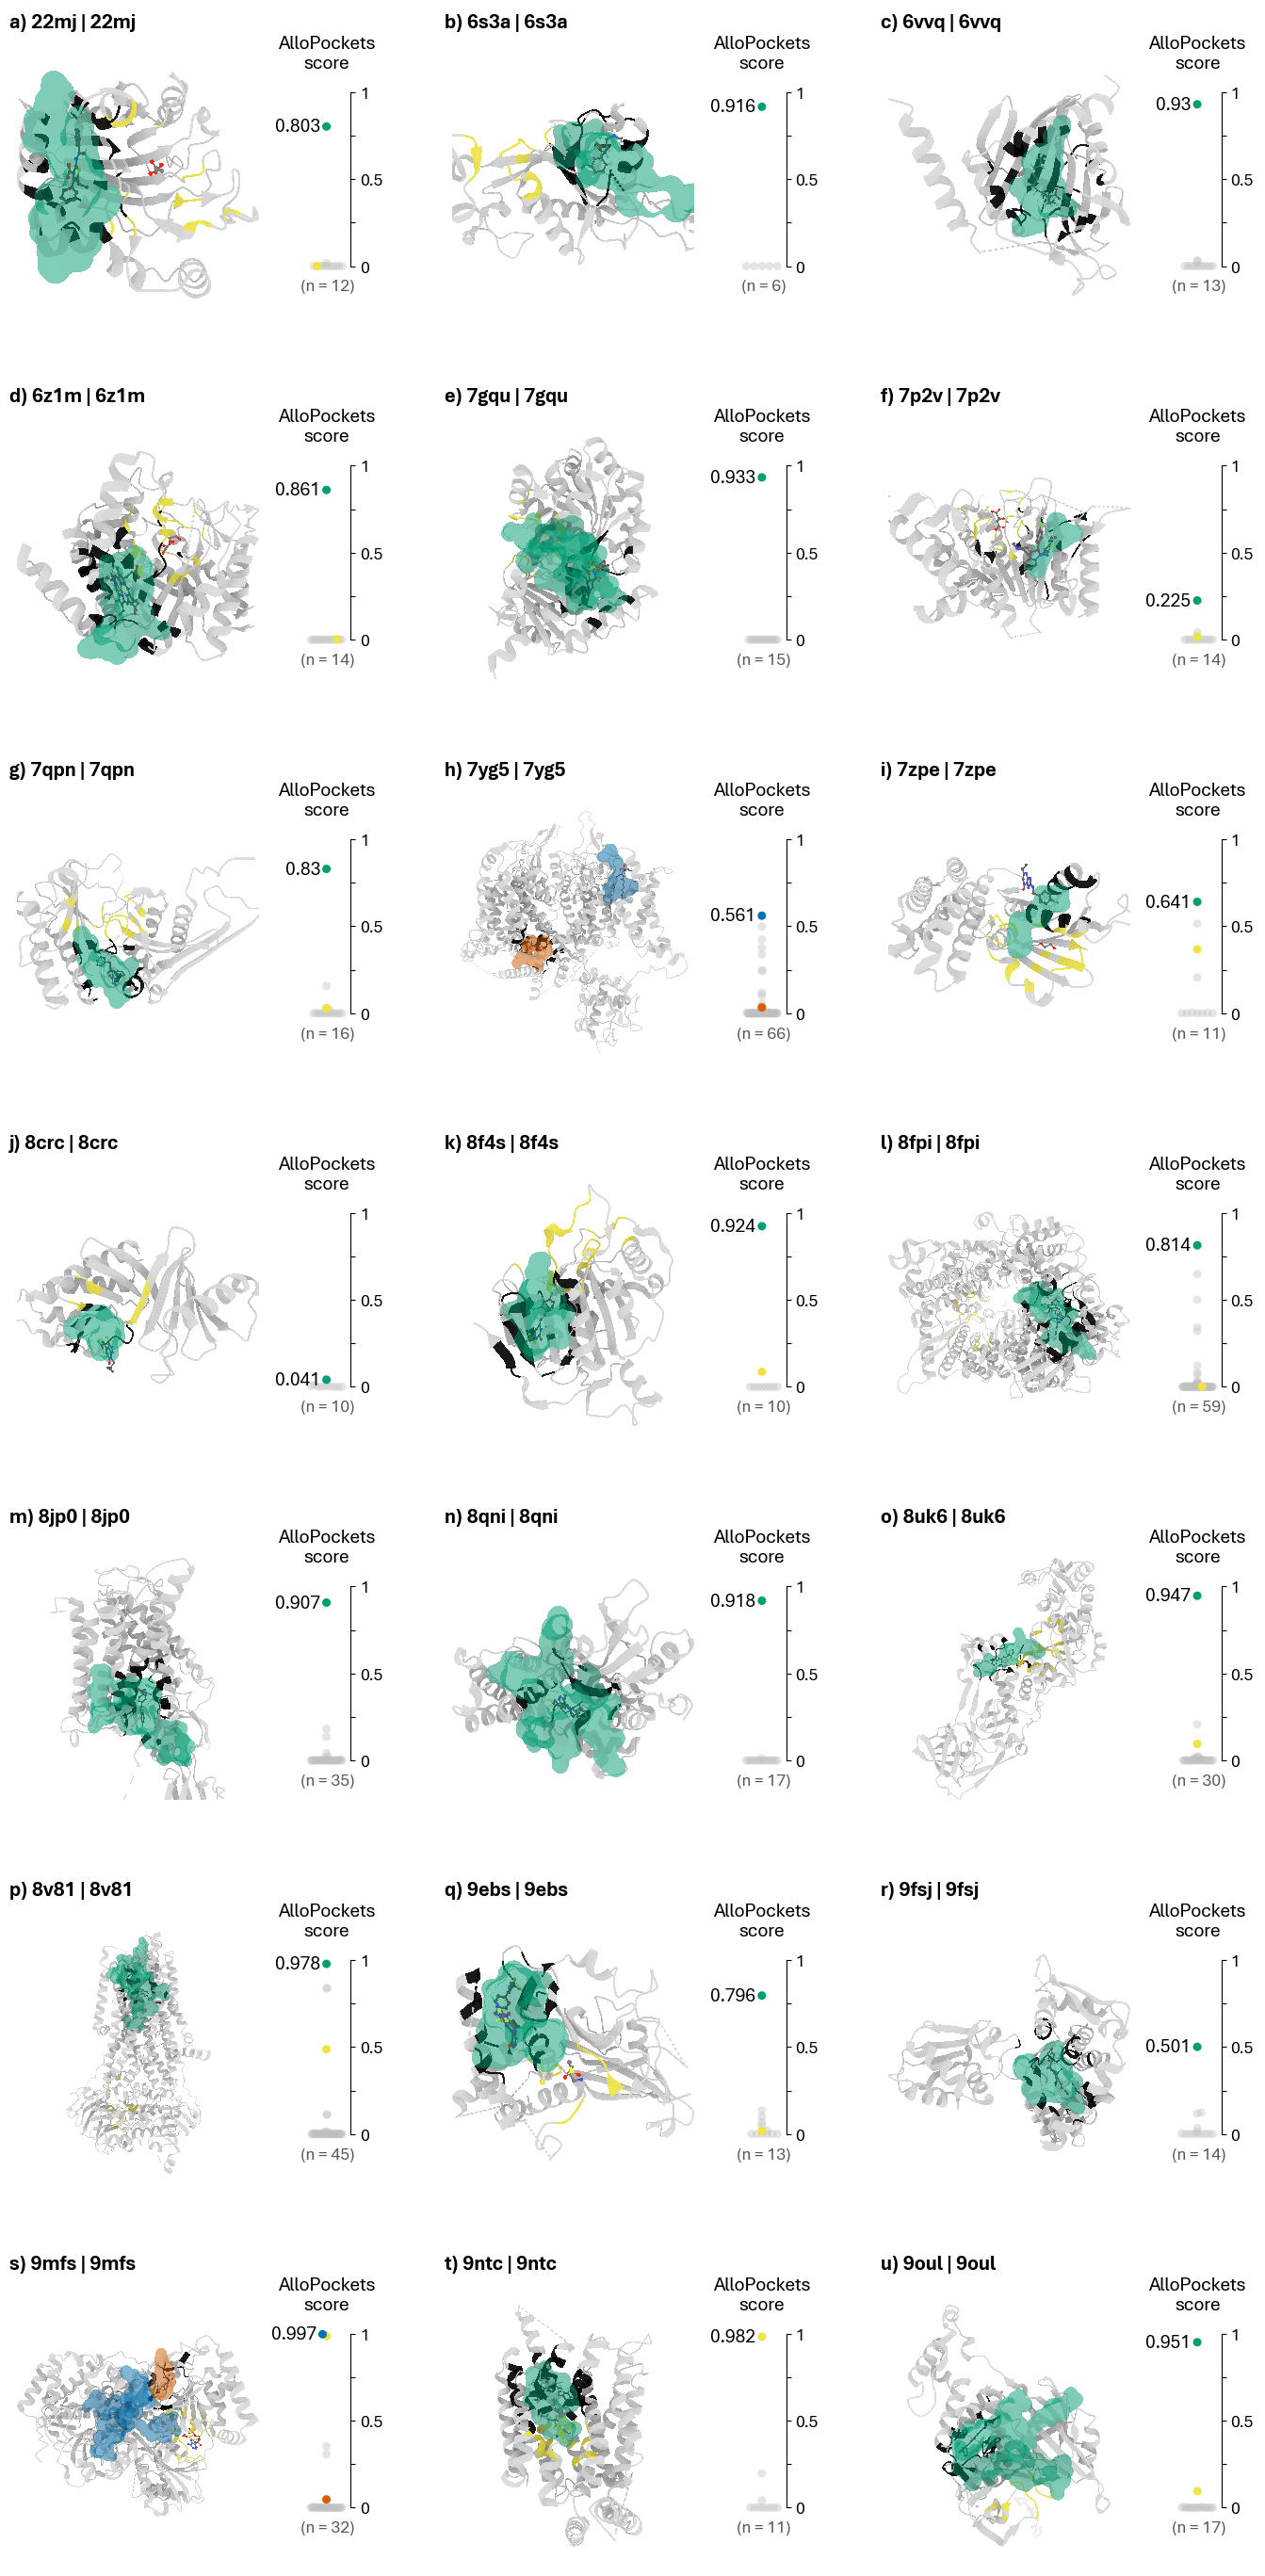

In [ ]:
from pathlib import Path
from string import ascii_lowercase

import matplotlib.image as mpimg
from matplotlib import rcParams

names = {
    "22mj": "22mj | 22mj",
    "6s3a": "6s3a | 6s3a",
    "6vvq": "6vvq | 6vvq",
    "6z1m": "6z1m | 6z1m",
    "7gqu": "7gqu | 7gqu",
    "7p2v": "7p2v | 7p2v",
    "7qpn": "7qpn | 7qpn",
    "7yg5": "7yg5 | 7yg5",
    "7zpe": "7zpe | 7zpe",
    "8crc": "8crc | 8crc",
    "8f4s": "8f4s | 8f4s",
    "8fpi": "8fpi | 8fpi",
    "8jp0": "8jp0 | 8jp0",
    "8qni": "8qni | 8qni",
    "8uk6": "8uk6 | 8uk6",
    "8v81": "8v81 | 8v81",
    "9ebs": "9ebs | 9ebs",
    "9fsj": "9fsj | 9fsj",
    "9mfs": "9mfs | 9mfs",
    "9ntc": "9ntc | 9ntc",
    "9oul": "9oul | 9oul",
}
# Titles can use Matplotlib mathtext for italics, e.g. r"22mj | $\it{Protein\ Name}$"
# TODO: add explicit line breaks ("\n") for titles that should span two lines.

figure_config = {
    "ncols": 3,
    "nrows": 7,
    "figsize": (14, 28),
    "font_scale": 1.15,
    "left": 0.04,
    "right": 0.985,
    "top": 0.99,
    "bottom": 0.02,
    "wspace": 0.16,
    "hspace": 0.18,
    "panel_hspace": 0.008,
    "panel_wspace": 0.02,
    "title_height_ratio": 0.11,
    "image_height_ratio": 0.89,
    "protein_width_ratio": 0.72,
    "scatter_width_ratio": 0.32,
    "protein_max_width": 0.94,
    "protein_max_height": 0.94,
    "panel_label_fontsize": 14,
    "panel_label_weight": "bold",
    "title_fontsize": 14,
    "header_fontweight": "bold",
    "label_x": 0.0,
    "title_x": 0.12,
    "title_y": 0.6,
    "panel_facecolor": "none",
    "figure_facecolor": "none",
    "scatter_config": {
        **scatter_config,
        "figsize": (2.2, 2.8),
        "point_size": 42,
        "tick_fontsize": 11.8,
        "label_fontsize": 12.8,
        "xlabel_fontsize": 11.8,
        "score_title_fontsize": 13.4,
    },
    "output_path": "images/multipanel_figure.svg",
}

font_scale = figure_config["font_scale"]
figure_config["panel_label_fontsize"] *= font_scale
figure_config["title_fontsize"] *= font_scale
for key in ["tick_fontsize", "label_fontsize", "xlabel_fontsize", "score_title_fontsize"]:
    figure_config["scatter_config"][key] *= font_scale

plt.rcParams["font.family"] = "Aptos"
rcParams["svg.fonttype"] = "none"


def draw_centered_image(ax, image_path, max_width=0.94, max_height=0.94):
    image_path = Path(image_path)
    if not image_path.is_file():
        raise FileNotFoundError(f"Missing protein render for {image_path.stem}: {image_path}")

    img = mpimg.imread(image_path)
    height, width = img.shape[:2]
    aspect = width / height

    disp_width = max_width
    disp_height = disp_width / aspect
    if disp_height > max_height:
        disp_height = max_height
        disp_width = disp_height * aspect

    x0 = (1 - disp_width) / 2
    x1 = x0 + disp_width
    y0 = (1 - disp_height) / 2
    y1 = y0 + disp_height

    ax.imshow(
        img,
        extent=(x0, x1, y0, y1),
        aspect="auto",
        interpolation="none",
        resample=False,
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.set_facecolor("none")
    ax.axis("off")


pdb_order = list(names)
assert len(pdb_order) == figure_config["ncols"] * figure_config["nrows"]

fig = plt.figure(figsize=figure_config["figsize"], facecolor=figure_config["figure_facecolor"])
outer = fig.add_gridspec(
    figure_config["nrows"],
    figure_config["ncols"],
    left=figure_config["left"],
    right=figure_config["right"],
    top=figure_config["top"],
    bottom=figure_config["bottom"],
    wspace=figure_config["wspace"],
    hspace=figure_config["hspace"],
)

for panel_idx, pdb_id in enumerate(pdb_order):
    row = panel_idx // figure_config["ncols"]
    col = panel_idx % figure_config["ncols"]
    header = f"{ascii_lowercase[panel_idx]}) {names[pdb_id]}"

    panel = outer[row, col].subgridspec(
        2,
        1,
        height_ratios=[figure_config["title_height_ratio"], figure_config["image_height_ratio"]],
        hspace=figure_config["panel_hspace"],
    )

    title_ax = fig.add_subplot(panel[0])
    title_ax.set_facecolor(figure_config["panel_facecolor"])
    title_ax.axis("off")
    title_ax.text(
        figure_config["label_x"],
        figure_config["title_y"],
        header,
        fontsize=figure_config["title_fontsize"],
        fontweight=figure_config["header_fontweight"],
        ha="left",
        va="center",
    )

    content = panel[1].subgridspec(
        1,
        2,
        width_ratios=[figure_config["protein_width_ratio"], figure_config["scatter_width_ratio"]],
        wspace=figure_config["panel_wspace"],
    )

    protein_ax = fig.add_subplot(content[0])
    protein_ax.set_facecolor(figure_config["panel_facecolor"])
    draw_centered_image(
        protein_ax,
        Path("images") / f"{pdb_id}.png",
        max_width=figure_config["protein_max_width"],
        max_height=figure_config["protein_max_height"],
    )

    scatter_host_ax = fig.add_subplot(content[1])
    scatter_host_ax.set_facecolor(figure_config["panel_facecolor"])
    scatter_host_ax.axis("off")
    scatter_ax = scatter_host_ax.inset_axes([0.15, 0.21, 0.68, 0.62])
    scatter_ax.set_facecolor("none")
    plot_scatter_panel(
        pdb_id,
        df,
        ax=scatter_ax,
        config=figure_config["scatter_config"],
        show_xlabel=True,
        show_score_title=True,
    )

fig.savefig(figure_config["output_path"], transparent=True)
fig.savefig(
    Path(figure_config["output_path"]).with_suffix(".pdf"),#"images/multipanel_figure.pdf",
    bbox_inches="tight",
    pad_inches=0,
    transparent=True,
)
plt.show()
print(f"Saved multi-panel figure to {figure_config['output_path']}")


PosixPath('images/multipanel_figure.pdf')

## Ignorelight tests